In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import plotly.express as px

In [2]:
sns.set(
    font_scale=2,
    style     ='whitegrid',
    rc        ={'figure.figsize': (20, 7)}
)

In [3]:
sales_team = pd.read_csv('D:\\Программы\\Karpov.Courses - Аналитик данных (2022)\\Часть 1\\Задания\\Ноутбуки и датасеты\\Ноутбуки и датасеты\\6 задание\\sales_team.csv')
order_leads = pd.read_csv('D:\\Программы\\Karpov.Courses - Аналитик данных (2022)\\Часть 1\\Задания\\Ноутбуки и датасеты\\Ноутбуки и датасеты\\6 задание\\order_leads.csv')
invoices = pd.read_csv('D:\\Программы\\Karpov.Courses - Аналитик данных (2022)\\Часть 1\\Задания\\Ноутбуки и датасеты\\Ноутбуки и датасеты\\6 задание\\invoices.csv')

In [4]:
sales_team.head()

,Sales Rep,Sales Rep Id,Company Name,Company Id
0,William Taylor,ZTZA0ZLYZR85PTUJ,Melancholy Social-Role,D0AUXPP07H6AVSGD
1,William Taylor,ZTZA0ZLYZR85PTUJ,Pee-Wee Pigeon,TJW99R4RWH02INII
2,William Taylor,ZTZA0ZLYZR85PTUJ,Vaginal 36-Year-Old,3S20IO1O1DYXMUNU
3,William Taylor,ZTZA0ZLYZR85PTUJ,Unhurried Musician'S,FDWW0TQRPGMVI2A7
4,William Taylor,ZTZA0ZLYZR85PTUJ,Comprehensive Lists,C30FY83UNLVBA0O3


In [5]:
order_leads['Date'] = pd.to_datetime(order_leads.Date)

In [6]:
order_leads.columns = order_leads.columns.str.replace(' ', '_')

In [7]:
order_leads.head()

,Order_Id,Company_Id,Company_Name,Date,Order_Value,Converted
0,HZSXLI1IS9RGABZW,D0AUXPP07H6AVSGD,Melancholy Social-Role,2017-10-13,6952,0
1,582WPS3OW8T6YT0R,D0AUXPP07H6AVSGD,Melancholy Social-Role,2017-09-02,7930,0
2,KRF65MQZBOYG4Y9T,D0AUXPP07H6AVSGD,Melancholy Social-Role,2016-12-21,5538,1
3,N3EDZ5V1WGSWW828,D0AUXPP07H6AVSGD,Melancholy Social-Role,2018-06-03,1113,0
4,QXBC8COXEXGFSPLP,D0AUXPP07H6AVSGD,Melancholy Social-Role,2014-07-26,4596,0


In [8]:
cr_by_day = order_leads.groupby(['Date']) \
    .agg({'Converted' : 'mean'})\
    .rename(columns={'Converted' : 'CR'})\
    .sort_values('Date')

<Axes: xlabel='Date'>

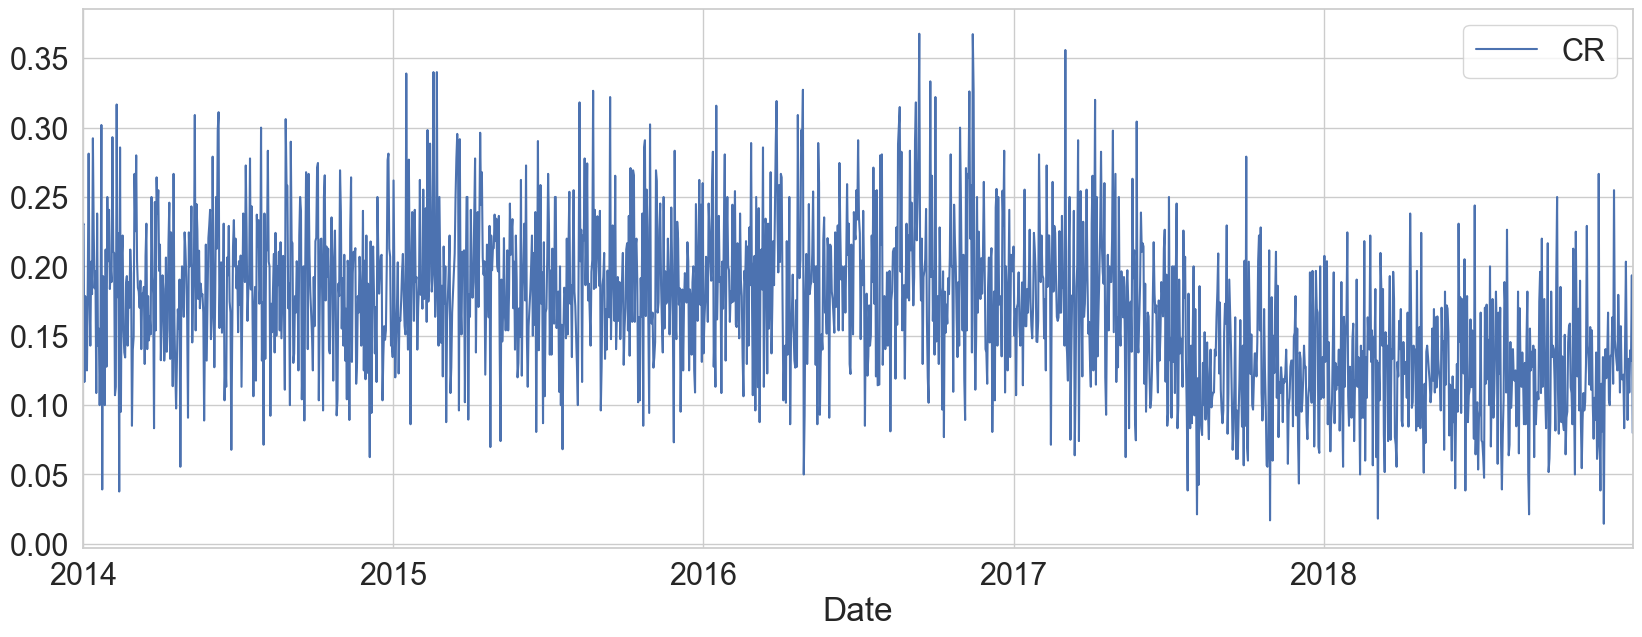

In [9]:
cr_by_day.plot()

In [10]:
cr_by_day_rolling = order_leads.groupby(['Date']) \
    .agg({'Converted' : 'mean'})\
    .rename(columns={'Converted' : 'CR'})\
    .sort_values('Date')\
    .rolling(30).mean()

C:\Users\user\AppData\Local\Temp\ipykernel_6948\1676494013.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:.0%}'.format(n) for n in ax.get_yticks()])


[Text(0, 0.1, '10%'),
 Text(0, 0.12000000000000001, '12%'),
 Text(0, 0.14, '14%'),
 Text(0, 0.16, '16%'),
 Text(0, 0.18, '18%'),
 Text(0, 0.2, '20%'),
 Text(0, 0.22, '22%'),
 Text(0, 0.24000000000000002, '24%')]

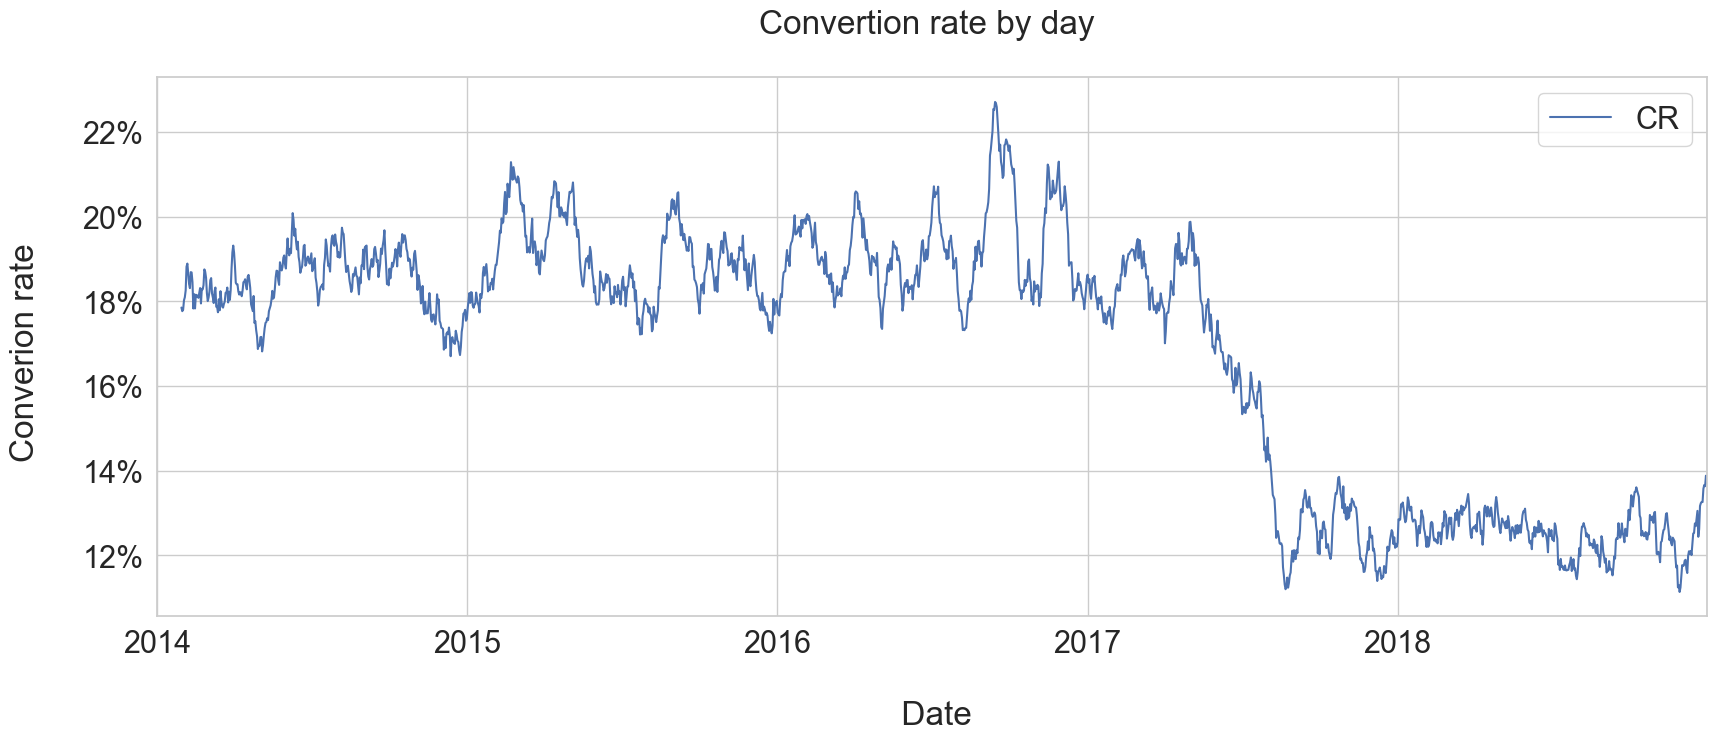

In [11]:
ax = cr_by_day_rolling.plot()
ax.set_title('Convertion rate by day \n')
ax.set_ylabel('Converion rate \n')
ax.set_xlabel('\n Date')
ax.set_yticklabels(['{:.0%}'.format(n) for n in ax.get_yticks()])

